In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


e:\Projects\LoadForecasting\aimlloadforecasting_b4\lfvenv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)

print("[INFO] Loaded feature list:", len(feature_names))


[INFO] Loaded feature list: 17


In [3]:
DATA_PATH = "../data/processed/featured_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

print("[INFO] Dataset loaded:", df.shape)
df.head()


[INFO] Dataset loaded: (43657, 19)


,timestamp,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,load_lag_1,load_lag_24,load_lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
0,2015-01-07 23:00:00,28222.0,2.2,32,-12.6,52.0,1015.0,23,2,1,0,-0.258819,0.965926,31404.0,25555.0,22734.0,31718.583333,5933.401136,27376.958333
1,2015-01-08 00:00:00,25790.0,0.8,28,-15.6,43.0,1235.0,0,3,1,0,0.000000,1.000000,28222.0,23341.0,22734.0,31820.625000,5802.679387,27395.148810
2,2015-01-08 01:00:00,24481.0,-0.6,25,-18.0,36.0,1443.0,1,3,1,0,0.258819,0.965926,25790.0,22029.0,22734.0,31922.791667,5642.149945,27405.547619
3,2015-01-08 02:00:00,23883.0,-2.5,27,-19.2,36.0,1579.0,2,3,1,0,0.500000,0.866025,24481.0,21456.0,21286.0,32023.916667,5465.376314,27421.005952
4,2015-01-08 03:00:00,23761.0,-3.5,29,-19.2,36.0,1692.0,3,3,1,0,0.707107,0.707107,23883.0,21457.0,20264.0,32119.916667,5289.089097,27441.821429


In [4]:
TARGET = "load_actual"

X = df[feature_names].values
y = df[TARGET].values.reshape(-1, 1)


In [5]:
split_idx = int(len(X) * 0.8)

X_train_raw = X[:split_idx]
X_test_raw  = X[split_idx:]

y_train_raw = y[:split_idx]
y_test_raw  = y[split_idx:]


In [6]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_test_scaled  = scaler_y.transform(y_test_raw)


In [7]:
def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Lookback = 24 hours (captures local temporal patterns)
lookback = 24

X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, lookback)
X_test,  y_test  = create_sequences(X_test_scaled,  y_test_scaled,  lookback)


In [8]:
model = Sequential([
    Conv1D(64, kernel_size=3, activation="relu",
           input_shape=(lookback, X_train.shape[2])),
    MaxPooling1D(pool_size=2),

    Conv1D(32, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


e:\Projects\LoadForecasting\aimlloadforecasting_b4\lfvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 22, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,665 (53.38 KB)

 Trainable params: 13,665 (53.38 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train, 
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0090 - val_loss: 0.0026
Epoch 2/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0037 - val_loss: 0.0020
Epoch 3/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0029 - val_loss: 0.0018
Epoch 4/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 5/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0022 - val_loss: 0.0015
Epoch 6/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0021 - val_loss: 0.0013
Epoch 7/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 8/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 9/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 10/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 11/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 12/20
982/982 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

In [10]:
pred_scaled = model.predict(X_test)
pred = scaler_y.inverse_transform(pred_scaled)

y_test_actual = scaler_y.inverse_transform(y_test)

mae_cnn  = mean_absolute_error(y_test_actual, pred)
rmse_cnn = mean_squared_error(y_test_actual, pred) ** 0.5
mape_cnn = np.mean(np.abs((y_test_actual - pred) / y_test_actual)) * 100

print("CNN Results")
print("MAE :", mae_cnn)
print("RMSE:", rmse_cnn)
print("MAPE:", mape_cnn)


273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN Results
MAE : 478.70235770089283
RMSE: 659.4715796973964
MAPE: 1.7090698972066147


In [11]:
model.save("../saved_models/cnn_model.h5")
joblib.dump(scaler_X, "../saved_models/cnn_scaler_X.pkl")
joblib.dump(scaler_y, "../saved_models/cnn_scaler_y.pkl")

print("[INFO] CNN model and scalers saved")


[INFO] CNN model and scalers saved


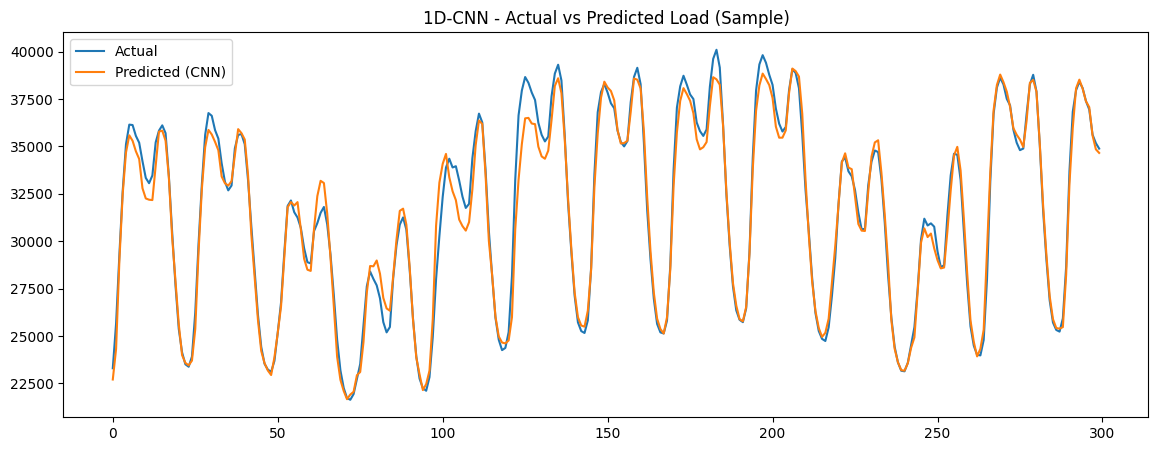

In [12]:
plt.figure(figsize=(14,5))
plt.plot(y_test_actual[:300], label="Actual")
plt.plot(pred[:300], label="Predicted (CNN)")
plt.legend()
plt.title("1D-CNN - Actual vs Predicted Load (Sample)")
plt.show()
